<!-- What: Introduce the notebook. Why: State the research scope clearly. -->
# COS700: NLP Experiments for 5G Network-Log Anomaly Detection

This Google Colab notebook runs **20 controlled experiments** using the supplied
`cleaned_5g_network_logs.csv` dataset.

- **Category 1:** TF-IDF vs Word2Vec and three hybrid strategies.
- **Category 2:** TF-IDF vs LogBERT and three hybrid strategies.
- **Classifiers:** Logistic Regression and Random Forest.
- **Validation policy:** fit representations on training data, tune thresholds and
  fusion weights on validation data, and evaluate the test data once.

Category 1 works at **log-entry level**. Category 2 works at **session level**
because LogBERT models ordered sequences of log keys.



<!-- What: List all experiments. Why: Make the comparison auditable. -->
## Experiment matrix

### Category 1 — TF-IDF vs Word2Vec

| Experiment | Representation | Classifier |
|---:|---|---|
| 1 | TF-IDF | Logistic Regression |
| 2 | TF-IDF | Random Forest |
| 3 | Word2Vec | Logistic Regression |
| 4 | Word2Vec | Random Forest |
| 5 | TF-IDF + Word2Vec concatenation | Logistic Regression |
| 6 | TF-IDF + Word2Vec concatenation | Random Forest |
| 7 | TF-IDF-weighted Word2Vec | Logistic Regression |
| 8 | TF-IDF-weighted Word2Vec | Random Forest |
| 9 | TF-IDF/Word2Vec decision fusion | Logistic Regression |
| 10 | TF-IDF/Word2Vec decision fusion | Random Forest |

### Category 2 — TF-IDF vs LogBERT

| Experiment | Representation | Classifier |
|---:|---|---|
| 1 | TF-IDF | Logistic Regression |
| 2 | TF-IDF | Random Forest |
| 3 | LogBERT | Logistic Regression |
| 4 | LogBERT | Random Forest |
| 5 | TF-IDF + LogBERT concatenation | Logistic Regression |
| 6 | TF-IDF + LogBERT concatenation | Random Forest |
| 7 | TF-IDF-weighted LogBERT | Logistic Regression |
| 8 | TF-IDF-weighted LogBERT | Random Forest |
| 9 | TF-IDF/LogBERT decision fusion | Logistic Regression |
| 10 | TF-IDF/LogBERT decision fusion | Random Forest |



In [1]:
# What: Install and import dependencies. Why: Prepare a reproducible Colab runtime.
import copy
import gc
import importlib.util
import json
import os
import random
import shutil
import subprocess
import sys
import time
import warnings
from collections import OrderedDict
from pathlib import Path

if importlib.util.find_spec("gensim") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "gensim>=4.3.3,<5"]
    )

import numpy as np
import pandas as pd
import scipy.linalg

# Some Colab SciPy builds no longer export triu, while Gensim still imports it.
if not hasattr(scipy.linalg, "triu"):
    scipy.linalg.triu = np.triu

import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from gensim.models import Word2Vec
from IPython.display import display
from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")



In [2]:
# What: Set paths and experiment controls. Why: Keep every run repeatable.
SEED = 42
RUN_MODE = "full"  # Change to "quick" only when testing the notebook.
DATA_PATH = Path(os.environ.get("COS700_DATA_PATH", "/content/cleaned_5g_network_logs.csv"))
OUTPUT_DIR = Path("/content/cos700_experiment_outputs")

RF_TREES = 300 if RUN_MODE == "full" else 60
W2V_EPOCHS = 10 if RUN_MODE == "full" else 3
LOGBERT_EPOCHS = 12 if RUN_MODE == "full" else 3
W2V_DIM = 100
LOGBERT_DIM = 64
BATCH_SIZE = 256

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Run mode: {RUN_MODE} | Device: {DEVICE} | Seed: {SEED}")



Run mode: full | Device: cuda | Seed: 42


In [3]:
# What: Load and validate the CSV. Why: Stop early if the wrong data is supplied.
if not DATA_PATH.exists():
    try:
        from google.colab import files

        print("Upload cleaned_5g_network_logs.csv")
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("No CSV was uploaded.")
        DATA_PATH = Path("/content") / next(iter(uploaded))
    except ImportError as exc:
        raise FileNotFoundError(
            f"Dataset not found at {DATA_PATH}. Set COS700_DATA_PATH or run in Colab."
        ) from exc

df = pd.read_csv(DATA_PATH)
required_columns = {
    "timestamp",
    "network_function",
    "severity",
    "log_text",
    "clean_text",
    "label",
    "target",
    "anomaly_type",
    "scenario_id",
    "session_id",
    "template_id",
    "split",
}
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="raise", utc=True)
df["target"] = df["target"].astype(int)
df["clean_text"] = df["clean_text"].fillna("").astype(str)
df = df.sort_values(["timestamp", "session_id"]).reset_index(drop=True)

assert set(df["split"].unique()) == {"train", "validation", "test"}
assert set(df["target"].unique()).issubset({0, 1})
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns from {DATA_PATH.name}.")



Upload cleaned_5g_network_logs.csv


Saving cleaned_5g_network_logs.csv to cleaned_5g_network_logs.csv
Loaded 50,000 rows and 12 columns from cleaned_5g_network_logs.csv.


In [4]:
# What: Audit balance, duplication, and leakage. Why: Interpret high scores cautiously.
split_audit = pd.crosstab(df["split"], df["target"], margins=True)
severity_audit = pd.crosstab(df["severity"], df["target"], margins=True)
session_split_counts = df.groupby("session_id")["split"].nunique()

train_clean = set(df.loc[df["split"] == "train", "clean_text"])
test_clean = set(df.loc[df["split"] == "test", "clean_text"])
train_templates = set(df.loc[df["split"] == "train", "template_id"])
test_templates = set(df.loc[df["split"] == "test", "template_id"])

audit_summary = pd.DataFrame(
    {
        "Check": [
            "Rows",
            "Unique cleaned messages",
            "Repeated cleaned-message rows",
            "Unique templates",
            "Sessions",
            "Sessions appearing in multiple splits",
            "Train/test cleaned-message overlap",
            "Train/test template overlap",
            "Cleaned messages mapping to both labels",
            "Templates mapping to both labels",
        ],
        "Value": [
            len(df),
            df["clean_text"].nunique(),
            int(df["clean_text"].duplicated().sum()),
            df["template_id"].nunique(),
            df["session_id"].nunique(),
            int((session_split_counts > 1).sum()),
            len(train_clean & test_clean),
            len(train_templates & test_templates),
            int((df.groupby("clean_text")["target"].nunique() > 1).sum()),
            int((df.groupby("template_id")["target"].nunique() > 1).sum()),
        ],
    }
)

display(split_audit)
display(severity_audit)
display(audit_summary)



target,0,1,All
split,,,
test,5625,1875,7500
train,26250,8750,35000
validation,5625,1875,7500
All,37500,12500,50000


target,0,1,All
severity,,,
CRITICAL,0,1000,1000
DEBUG,6000,0,6000
ERROR,0,6500,6500
INFO,27000,500,27500
NOTICE,4000,0,4000
WARNING,500,4500,5000
All,37500,12500,50000


,Check,Value
0,Rows,50000
1,Unique cleaned messages,1999
2,Repeated cleaned-message rows,48001
3,Unique templates,288
4,Sessions,8326
5,Sessions appearing in multiple splits,0
6,Train/test cleaned-message overlap,959
7,Train/test template overlap,216
8,Cleaned messages mapping to both labels,0
9,Templates mapping to both labels,0


In [5]:
# What: Create fixed log-entry splits. Why: Prevent training information from reaching the test set.
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

train_text = train_df["clean_text"].tolist()
val_text = val_df["clean_text"].tolist()
test_text = test_df["clean_text"].tolist()
y_train_1 = train_df["target"].to_numpy()
y_val_1 = val_df["target"].to_numpy()
y_test_1 = test_df["target"].to_numpy()

print(
    f"Category 1 rows — train: {len(train_df):,}, "
    f"validation: {len(val_df):,}, test: {len(test_df):,}"
)



Category 1 rows — train: 35,000, validation: 7,500, test: 7,500


In [6]:
# What: Define evaluation and classifier helpers. Why: Apply identical rules to every experiment.
def make_classifier(name):
    if name == "Logistic Regression":
        return LogisticRegression(
            max_iter=2_000,
            class_weight="balanced",
            solver="liblinear",
            random_state=SEED,
        )
    if name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=RF_TREES,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED,
        )
    raise ValueError(f"Unknown classifier: {name}")


def tune_threshold(y_true, probabilities):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    if len(thresholds) == 0:
        return 0.5, 0.0
    scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best = int(np.nanargmax(scores))
    return float(thresholds[best]), float(scores[best])


def probability_metrics(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "FPR": fp / (fp + tn) if (fp + tn) else 0.0,
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "PR_AUC": average_precision_score(y_true, probabilities),
    }


def run_classifier_experiment(
    experiment,
    category,
    representation,
    classifier_name,
    level,
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
):
    model = make_classifier(classifier_name)
    started = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started

    val_prob = model.predict_proba(X_val)[:, 1]
    threshold, _ = tune_threshold(y_val, val_prob)
    started = time.perf_counter()
    test_prob = model.predict_proba(X_test)[:, 1]
    predict_seconds = time.perf_counter() - started

    row = {
        "Experiment": experiment,
        "Category": category,
        "Representation": representation,
        "Classifier": classifier_name,
        "Evaluation_level": level,
        "Threshold": threshold,
        **probability_metrics(y_test, test_prob, threshold),
        "Fit_seconds": fit_seconds,
        "Predict_seconds": predict_seconds,
    }
    payload = {
        "val_prob": val_prob,
        "test_prob": test_prob,
        "threshold": threshold,
        "fit_seconds": fit_seconds,
        "predict_seconds": predict_seconds,
    }
    del model
    gc.collect()
    return row, payload


def tune_fusion(y_true, first_prob, second_prob):
    best = {"f1": -1.0, "alpha": 0.5, "threshold": 0.5}
    for alpha in np.linspace(0.0, 1.0, 21):
        combined = alpha * first_prob + (1.0 - alpha) * second_prob
        threshold, score = tune_threshold(y_true, combined)
        if score > best["f1"]:
            best = {"f1": score, "alpha": float(alpha), "threshold": threshold}
    return best



In [7]:
# What: Build Category 1 representations. Why: Compare lexical, semantic, and hybrid features.
tfidf_1 = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=20_000,
    sublinear_tf=True,
    dtype=np.float32,
)
Xtr_tfidf_1 = tfidf_1.fit_transform(train_text)
Xva_tfidf_1 = tfidf_1.transform(val_text)
Xte_tfidf_1 = tfidf_1.transform(test_text)

train_tokens = [text.split() for text in train_text]
val_tokens = [text.split() for text in val_text]
test_tokens = [text.split() for text in test_text]

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=W2V_DIM,
    window=5,
    min_count=2,
    workers=1,
    sg=1,
    seed=SEED,
    epochs=W2V_EPOCHS,
)

idf_lookup_1 = dict(zip(tfidf_1.get_feature_names_out(), tfidf_1.idf_))


def mean_word2vec(token_rows):
    rows = []
    for tokens in token_rows:
        vectors = [w2v_model.wv[token] for token in tokens if token in w2v_model.wv]
        rows.append(np.mean(vectors, axis=0) if vectors else np.zeros(W2V_DIM))
    return np.asarray(rows, dtype=np.float32)


def weighted_word2vec(token_rows):
    rows = []
    for tokens in token_rows:
        pairs = [
            (w2v_model.wv[token], idf_lookup_1.get(token, 0.0))
            for token in tokens
            if token in w2v_model.wv and token in idf_lookup_1
        ]
        if not pairs or sum(weight for _, weight in pairs) == 0:
            rows.append(np.zeros(W2V_DIM))
        else:
            vectors = np.vstack([vector for vector, _ in pairs])
            weights = np.asarray([weight for _, weight in pairs])
            rows.append(np.average(vectors, axis=0, weights=weights))
    return np.asarray(rows, dtype=np.float32)


Xtr_w2v_raw = mean_word2vec(train_tokens)
Xva_w2v_raw = mean_word2vec(val_tokens)
Xte_w2v_raw = mean_word2vec(test_tokens)
w2v_scaler = StandardScaler()
Xtr_w2v = w2v_scaler.fit_transform(Xtr_w2v_raw).astype(np.float32)
Xva_w2v = w2v_scaler.transform(Xva_w2v_raw).astype(np.float32)
Xte_w2v = w2v_scaler.transform(Xte_w2v_raw).astype(np.float32)

Xtr_weighted_w2v_raw = weighted_word2vec(train_tokens)
Xva_weighted_w2v_raw = weighted_word2vec(val_tokens)
Xte_weighted_w2v_raw = weighted_word2vec(test_tokens)
weighted_w2v_scaler = StandardScaler()
Xtr_weighted_w2v = weighted_w2v_scaler.fit_transform(Xtr_weighted_w2v_raw).astype(np.float32)
Xva_weighted_w2v = weighted_w2v_scaler.transform(Xva_weighted_w2v_raw).astype(np.float32)
Xte_weighted_w2v = weighted_w2v_scaler.transform(Xte_weighted_w2v_raw).astype(np.float32)

Xtr_concat_1 = hstack([Xtr_tfidf_1, csr_matrix(Xtr_w2v)], format="csr")
Xva_concat_1 = hstack([Xva_tfidf_1, csr_matrix(Xva_w2v)], format="csr")
Xte_concat_1 = hstack([Xte_tfidf_1, csr_matrix(Xte_w2v)], format="csr")

category_1_features = OrderedDict(
    [
        ("TF-IDF", (Xtr_tfidf_1, Xva_tfidf_1, Xte_tfidf_1)),
        ("Word2Vec", (Xtr_w2v, Xva_w2v, Xte_w2v)),
        (
            "TF-IDF + Word2Vec concatenation",
            (Xtr_concat_1, Xva_concat_1, Xte_concat_1),
        ),
        (
            "TF-IDF-weighted Word2Vec",
            (Xtr_weighted_w2v, Xva_weighted_w2v, Xte_weighted_w2v),
        ),
    ]
)
print("Category 1 feature sets are ready.")



Category 1 feature sets are ready.


In [8]:
# What: Run Category 1 experiments 1–8. Why: Test four representations with both classifiers.
category_1_results = []
category_1_predictions = {}
experiment_number = 1

for representation, (X_train, X_val, X_test) in category_1_features.items():
    for classifier_name in ["Logistic Regression", "Random Forest"]:
        row, payload = run_classifier_experiment(
            experiment=experiment_number,
            category="Category 1",
            representation=representation,
            classifier_name=classifier_name,
            level="Log entry",
            X_train=X_train,
            X_val=X_val,
            X_test=X_test,
            y_train=y_train_1,
            y_val=y_val_1,
            y_test=y_test_1,
        )
        category_1_results.append(row)
        category_1_predictions[(representation, classifier_name)] = payload
        print(f"Finished Category 1 experiment {experiment_number}: {representation} / {classifier_name}")
        experiment_number += 1



Finished Category 1 experiment 1: TF-IDF / Logistic Regression
Finished Category 1 experiment 2: TF-IDF / Random Forest
Finished Category 1 experiment 3: Word2Vec / Logistic Regression
Finished Category 1 experiment 4: Word2Vec / Random Forest
Finished Category 1 experiment 5: TF-IDF + Word2Vec concatenation / Logistic Regression
Finished Category 1 experiment 6: TF-IDF + Word2Vec concatenation / Random Forest
Finished Category 1 experiment 7: TF-IDF-weighted Word2Vec / Logistic Regression
Finished Category 1 experiment 8: TF-IDF-weighted Word2Vec / Random Forest


In [9]:
# What: Run Category 1 fusion experiments 9–10. Why: Combine independent model decisions.
for experiment_number, classifier_name in enumerate(
    ["Logistic Regression", "Random Forest"], start=9
):
    tfidf_payload = category_1_predictions[("TF-IDF", classifier_name)]
    w2v_payload = category_1_predictions[("Word2Vec", classifier_name)]
    fusion = tune_fusion(
        y_val_1,
        tfidf_payload["val_prob"],
        w2v_payload["val_prob"],
    )
    test_prob = (
        fusion["alpha"] * tfidf_payload["test_prob"]
        + (1.0 - fusion["alpha"]) * w2v_payload["test_prob"]
    )
    category_1_results.append(
        {
            "Experiment": experiment_number,
            "Category": "Category 1",
            "Representation": "Decision fusion: TF-IDF + Word2Vec",
            "Classifier": classifier_name,
            "Evaluation_level": "Log entry",
            "Threshold": fusion["threshold"],
            **probability_metrics(y_test_1, test_prob, fusion["threshold"]),
            "Fit_seconds": tfidf_payload["fit_seconds"] + w2v_payload["fit_seconds"],
            "Predict_seconds": tfidf_payload["predict_seconds"] + w2v_payload["predict_seconds"],
            "Fusion_weight_TFIDF": fusion["alpha"],
        }
    )
    print(
        f"Finished Category 1 experiment {experiment_number}: "
        f"fusion / {classifier_name} / TF-IDF weight={fusion['alpha']:.2f}"
    )



Finished Category 1 experiment 9: fusion / Logistic Regression / TF-IDF weight=0.00
Finished Category 1 experiment 10: fusion / Random Forest / TF-IDF weight=0.00


In [10]:
# What: Show the Category 1 results table. Why: Compare all ten experiments together.
category_1_table = (
    pd.DataFrame(category_1_results)
    .sort_values("Experiment")
    .reset_index(drop=True)
)
assert category_1_table["Experiment"].tolist() == list(range(1, 11))

category_1_display_columns = [
    "Experiment",
    "Representation",
    "Classifier",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "FPR",
    "ROC_AUC",
    "PR_AUC",
    "Threshold",
]
print("CATEGORY 1 RESULTS — TF-IDF VS WORD2VEC")
display(category_1_table[category_1_display_columns].round(4))



CATEGORY 1 RESULTS — TF-IDF VS WORD2VEC


,Experiment,Representation,Classifier,Accuracy,Precision,Recall,F1,FPR,ROC_AUC,PR_AUC,Threshold
0,1,TF-IDF,Logistic Regression,0.9976,1.0000,0.9904,0.9952,0.0000,1.0000,1.0000,0.8836
1,2,TF-IDF,Random Forest,0.9631,1.0000,0.8523,0.9202,0.0000,1.0000,1.0000,0.8100
2,3,Word2Vec,Logistic Regression,0.9968,0.9995,0.9877,0.9936,0.0002,1.0000,0.9999,0.9681
3,4,Word2Vec,Random Forest,0.9789,1.0000,0.9157,0.9560,0.0000,0.9999,0.9996,0.8367
4,5,TF-IDF + Word2Vec concatenation,Logistic Regression,0.9963,0.9995,0.9856,0.9925,0.0002,1.0000,0.9999,0.9701
5,6,TF-IDF + Word2Vec concatenation,Random Forest,0.9612,1.0000,0.8448,0.9159,0.0000,1.0000,1.0000,0.8433
6,7,TF-IDF-weighted Word2Vec,Logistic Regression,0.9927,1.0000,0.9707,0.9851,0.0000,1.0000,1.0000,0.9940
7,8,TF-IDF-weighted Word2Vec,Random Forest,0.9688,1.0000,0.8752,0.9334,0.0000,0.9999,0.9996,0.8900
8,9,Decision fusion: TF-IDF + Word2Vec,Logistic Regression,0.9968,0.9995,0.9877,0.9936,0.0002,1.0000,0.9999,0.9681
9,10,Decision fusion: TF-IDF + Word2Vec,Random Forest,0.9789,1.0000,0.9157,0.9560,0.0000,0.9999,0.9996,0.8367


<!-- What: Introduce Category 2. Why: Explain the sequence-level comparison. -->
## Category 2: TF-IDF vs LogBERT

Logs are grouped by `session_id` and ordered by timestamp. The LogBERT-style
encoder uses masked log-key prediction plus a hypersphere compactness loss on
normal training sessions. Its contextual features are then classified by
Logistic Regression or Random Forest, as required by the experiment design.



In [11]:
# What: Build session data and TF-IDF features. Why: Compare all Category 2 models fairly.
session_records = []
for session_id, group in df.groupby("session_id", sort=False):
    group = group.sort_values("timestamp")
    if group["split"].nunique() != 1 or group["target"].nunique() != 1:
        raise ValueError(f"Session {session_id} crosses splits or labels.")
    session_records.append(
        {
            "session_id": session_id,
            "split": group["split"].iloc[0],
            "target": int(group["target"].iloc[0]),
            "anomaly_type": group["anomaly_type"].iloc[0],
            "session_text": " [EVENT] ".join(group["clean_text"].tolist()),
            "log_keys": group["template_id"].astype(str).tolist(),
        }
    )

session_df = pd.DataFrame(session_records)
train_sessions = session_df[session_df["split"] == "train"].reset_index(drop=True)
val_sessions = session_df[session_df["split"] == "validation"].reset_index(drop=True)
test_sessions = session_df[session_df["split"] == "test"].reset_index(drop=True)

y_train_2 = train_sessions["target"].to_numpy()
y_val_2 = val_sessions["target"].to_numpy()
y_test_2 = test_sessions["target"].to_numpy()

tfidf_2 = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=25_000,
    sublinear_tf=True,
    dtype=np.float32,
)
Xtr_tfidf_2 = tfidf_2.fit_transform(train_sessions["session_text"])
Xva_tfidf_2 = tfidf_2.transform(val_sessions["session_text"])
Xte_tfidf_2 = tfidf_2.transform(test_sessions["session_text"])

print(
    f"Category 2 sessions — train: {len(train_sessions):,}, "
    f"validation: {len(val_sessions):,}, test: {len(test_sessions):,}"
)



Category 2 sessions — train: 5,834, validation: 1,246, test: 1,246


In [12]:
# What: Define the LogBERT-style encoder. Why: Learn contextual log-sequence features.
PAD_ID, DIST_ID, MASK_ID, UNK_ID = 0, 1, 2, 3
SPECIAL_TOKENS = {"[PAD]": PAD_ID, "[DIST]": DIST_ID, "[MASK]": MASK_ID, "[UNK]": UNK_ID}

log_key_vocab = dict(SPECIAL_TOKENS)
for key in sorted({key for sequence in train_sessions["log_keys"] for key in sequence}):
    if key not in log_key_vocab:
        log_key_vocab[key] = len(log_key_vocab)

MAX_EVENTS = max(len(sequence) for sequence in train_sessions["log_keys"])
MAX_SEQUENCE_LENGTH = MAX_EVENTS + 1  # Add the DIST token.


def map_log_keys(sequence):
    return [log_key_vocab.get(key, UNK_ID) for key in sequence[:MAX_EVENTS]]


class MaskedLogKeyDataset(Dataset):
    def __init__(self, sequences, mask_ratio=0.30):
        self.sequences = list(sequences)
        self.mask_ratio = mask_ratio

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        event_ids = map_log_keys(self.sequences[index])
        input_ids = torch.tensor([DIST_ID] + event_ids, dtype=torch.long)
        labels = torch.full_like(input_ids, -100)
        event_positions = torch.arange(1, len(input_ids))
        number_to_mask = max(1, int(round(len(event_positions) * self.mask_ratio)))
        selected = event_positions[torch.randperm(len(event_positions))[:number_to_mask]]
        labels[selected] = input_ids[selected]
        input_ids[selected] = MASK_ID
        return input_ids, labels


class PlainLogKeyDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = list(sequences)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        event_ids = map_log_keys(self.sequences[index])
        return torch.tensor([DIST_ID] + event_ids, dtype=torch.long)


def masked_collate(batch):
    input_ids, labels = zip(*batch)
    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=PAD_ID)
    labels = pad_sequence(labels, batch_first=True, padding_value=-100)
    return input_ids, labels, input_ids.eq(PAD_ID)


def plain_collate(batch):
    input_ids = pad_sequence(batch, batch_first=True, padding_value=PAD_ID)
    return input_ids, input_ids.eq(PAD_ID)


class LogBERTEncoder(nn.Module):
    def __init__(self, vocab_size, max_length, model_dim=64):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, model_dim, padding_idx=PAD_ID)
        self.position_embedding = nn.Embedding(max_length, model_dim)
        layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=4,
            dim_feedforward=256,
            dropout=0.10,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.output_norm = nn.LayerNorm(model_dim)
        self.mlm_head = nn.Linear(model_dim, vocab_size)

    def forward(self, input_ids, padding_mask):
        positions = torch.arange(input_ids.size(1), device=input_ids.device).unsqueeze(0)
        hidden = self.token_embedding(input_ids) + self.position_embedding(positions)
        hidden = self.encoder(hidden, src_key_padding_mask=padding_mask)
        hidden = self.output_norm(hidden)
        return self.mlm_head(hidden), hidden


logbert = LogBERTEncoder(
    vocab_size=len(log_key_vocab),
    max_length=MAX_SEQUENCE_LENGTH,
    model_dim=LOGBERT_DIM,
).to(DEVICE)
print(f"LogBERT vocabulary: {len(log_key_vocab)} keys | Maximum events: {MAX_EVENTS}")



LogBERT vocabulary: 220 keys | Maximum events: 7


In [13]:
# What: Train LogBERT on normal sessions. Why: Learn normal sequence patterns without test leakage.
normal_train_sequences = train_sessions.loc[train_sessions["target"] == 0, "log_keys"].tolist()
normal_val_sequences = val_sessions.loc[val_sessions["target"] == 0, "log_keys"].tolist()

train_loader = DataLoader(
    MaskedLogKeyDataset(normal_train_sequences),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=masked_collate,
    num_workers=0,
)
val_loader = DataLoader(
    MaskedLogKeyDataset(normal_val_sequences),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=masked_collate,
    num_workers=0,
)
center_loader = DataLoader(
    PlainLogKeyDataset(normal_train_sequences),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=plain_collate,
    num_workers=0,
)


def calculate_center(model, loader):
    model.eval()
    vectors = []
    with torch.no_grad():
        for input_ids, padding_mask in loader:
            input_ids = input_ids.to(DEVICE)
            padding_mask = padding_mask.to(DEVICE)
            _, hidden = model(input_ids, padding_mask)
            vectors.append(hidden[:, 0].cpu())
    return torch.cat(vectors).mean(dim=0).to(DEVICE)


hypersphere_center = calculate_center(logbert, center_loader).detach()
optimizer = torch.optim.AdamW(logbert.parameters(), lr=1e-3, weight_decay=1e-4)
mlm_loss_function = nn.CrossEntropyLoss(ignore_index=-100)
VHM_WEIGHT = 0.10
PATIENCE = 3


def logbert_epoch(model, loader, training):
    model.train(training)
    total_loss = 0.0
    for input_ids, labels, padding_mask in loader:
        input_ids = input_ids.to(DEVICE)
        labels = labels.to(DEVICE)
        padding_mask = padding_mask.to(DEVICE)
        with torch.set_grad_enabled(training):
            logits, hidden = model(input_ids, padding_mask)
            mlm_loss = mlm_loss_function(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
            vhm_loss = ((hidden[:, 0] - hypersphere_center) ** 2).mean()
            loss = mlm_loss + VHM_WEIGHT * vhm_loss
            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        total_loss += loss.item() * input_ids.size(0)
    return total_loss / len(loader.dataset)


logbert_history = []
best_state = None
best_validation_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(1, LOGBERT_EPOCHS + 1):
    train_loss = logbert_epoch(logbert, train_loader, training=True)
    validation_loss = logbert_epoch(logbert, val_loader, training=False)
    logbert_history.append(
        {"epoch": epoch, "train_loss": train_loss, "validation_loss": validation_loss}
    )
    print(
        f"Epoch {epoch:02d} | train loss={train_loss:.4f} | "
        f"validation loss={validation_loss:.4f}"
    )
    if validation_loss < best_validation_loss - 1e-4:
        best_validation_loss = validation_loss
        best_state = copy.deepcopy(logbert.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print("Early stopping applied.")
            break

if best_state is not None:
    logbert.load_state_dict(best_state)
logbert.eval()
logbert_history = pd.DataFrame(logbert_history)



Epoch 01 | train loss=5.1518 | validation loss=4.7989
Epoch 02 | train loss=4.6597 | validation loss=4.4834
Epoch 03 | train loss=4.2535 | validation loss=3.8771
Epoch 04 | train loss=3.6239 | validation loss=3.2564
Epoch 05 | train loss=3.1040 | validation loss=2.8760
Epoch 06 | train loss=2.8244 | validation loss=2.7010
Epoch 07 | train loss=2.6815 | validation loss=2.6246
Epoch 08 | train loss=2.6221 | validation loss=2.5877
Epoch 09 | train loss=2.5896 | validation loss=2.5700
Epoch 10 | train loss=2.5715 | validation loss=2.5575
Epoch 11 | train loss=2.5598 | validation loss=2.5431
Epoch 12 | train loss=2.5474 | validation loss=2.5470


In [14]:
# What: Extract LogBERT and weighted LogBERT features. Why: Supply contextual vectors to both classifiers.
key_tfidf = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
)
key_tfidf.fit([" ".join(sequence) for sequence in train_sessions["log_keys"]])
key_idf = dict(zip(key_tfidf.get_feature_names_out(), key_tfidf.idf_))
unknown_key_weight = float(np.max(key_tfidf.idf_))


def extract_logbert_features(sequences, batch_size=512):
    dist_vectors = []
    weighted_vectors = []
    logbert.eval()
    with torch.no_grad():
        for start in range(0, len(sequences), batch_size):
            batch_sequences = sequences[start : start + batch_size]
            tensors = [
                torch.tensor([DIST_ID] + map_log_keys(sequence), dtype=torch.long)
                for sequence in batch_sequences
            ]
            input_ids = pad_sequence(tensors, batch_first=True, padding_value=PAD_ID).to(DEVICE)
            padding_mask = input_ids.eq(PAD_ID)
            _, hidden = logbert(input_ids, padding_mask)
            dist_vectors.append(hidden[:, 0].cpu().numpy())

            for row_index, sequence in enumerate(batch_sequences):
                usable_keys = sequence[:MAX_EVENTS]
                event_vectors = hidden[row_index, 1 : 1 + len(usable_keys)].cpu().numpy()
                weights = np.asarray(
                    [key_idf.get(key, unknown_key_weight) for key in usable_keys],
                    dtype=np.float32,
                )
                weighted_vectors.append(np.average(event_vectors, axis=0, weights=weights))

    return (
        np.vstack(dist_vectors).astype(np.float32),
        np.vstack(weighted_vectors).astype(np.float32),
    )


Xtr_logbert_raw, Xtr_weighted_logbert_raw = extract_logbert_features(
    train_sessions["log_keys"].tolist()
)
Xva_logbert_raw, Xva_weighted_logbert_raw = extract_logbert_features(
    val_sessions["log_keys"].tolist()
)
Xte_logbert_raw, Xte_weighted_logbert_raw = extract_logbert_features(
    test_sessions["log_keys"].tolist()
)

logbert_scaler = StandardScaler()
Xtr_logbert = logbert_scaler.fit_transform(Xtr_logbert_raw).astype(np.float32)
Xva_logbert = logbert_scaler.transform(Xva_logbert_raw).astype(np.float32)
Xte_logbert = logbert_scaler.transform(Xte_logbert_raw).astype(np.float32)

weighted_logbert_scaler = StandardScaler()
Xtr_weighted_logbert = weighted_logbert_scaler.fit_transform(
    Xtr_weighted_logbert_raw
).astype(np.float32)
Xva_weighted_logbert = weighted_logbert_scaler.transform(
    Xva_weighted_logbert_raw
).astype(np.float32)
Xte_weighted_logbert = weighted_logbert_scaler.transform(
    Xte_weighted_logbert_raw
).astype(np.float32)

Xtr_concat_2 = hstack([Xtr_tfidf_2, csr_matrix(Xtr_logbert)], format="csr")
Xva_concat_2 = hstack([Xva_tfidf_2, csr_matrix(Xva_logbert)], format="csr")
Xte_concat_2 = hstack([Xte_tfidf_2, csr_matrix(Xte_logbert)], format="csr")

category_2_features = OrderedDict(
    [
        ("TF-IDF", (Xtr_tfidf_2, Xva_tfidf_2, Xte_tfidf_2)),
        ("LogBERT", (Xtr_logbert, Xva_logbert, Xte_logbert)),
        (
            "TF-IDF + LogBERT concatenation",
            (Xtr_concat_2, Xva_concat_2, Xte_concat_2),
        ),
        (
            "TF-IDF-weighted LogBERT",
            (Xtr_weighted_logbert, Xva_weighted_logbert, Xte_weighted_logbert),
        ),
    ]
)
print("Category 2 feature sets are ready.")



Category 2 feature sets are ready.


In [15]:
# What: Run Category 2 experiments 1–8. Why: Test four session representations with both classifiers.
category_2_results = []
category_2_predictions = {}
experiment_number = 1

for representation, (X_train, X_val, X_test) in category_2_features.items():
    for classifier_name in ["Logistic Regression", "Random Forest"]:
        row, payload = run_classifier_experiment(
            experiment=experiment_number,
            category="Category 2",
            representation=representation,
            classifier_name=classifier_name,
            level="Session",
            X_train=X_train,
            X_val=X_val,
            X_test=X_test,
            y_train=y_train_2,
            y_val=y_val_2,
            y_test=y_test_2,
        )
        category_2_results.append(row)
        category_2_predictions[(representation, classifier_name)] = payload
        print(f"Finished Category 2 experiment {experiment_number}: {representation} / {classifier_name}")
        experiment_number += 1



Finished Category 2 experiment 1: TF-IDF / Logistic Regression
Finished Category 2 experiment 2: TF-IDF / Random Forest
Finished Category 2 experiment 3: LogBERT / Logistic Regression
Finished Category 2 experiment 4: LogBERT / Random Forest
Finished Category 2 experiment 5: TF-IDF + LogBERT concatenation / Logistic Regression
Finished Category 2 experiment 6: TF-IDF + LogBERT concatenation / Random Forest
Finished Category 2 experiment 7: TF-IDF-weighted LogBERT / Logistic Regression
Finished Category 2 experiment 8: TF-IDF-weighted LogBERT / Random Forest


In [16]:
# What: Run Category 2 fusion experiments 9–10. Why: Combine independent TF-IDF and LogBERT decisions.
for experiment_number, classifier_name in enumerate(
    ["Logistic Regression", "Random Forest"], start=9
):
    tfidf_payload = category_2_predictions[("TF-IDF", classifier_name)]
    logbert_payload = category_2_predictions[("LogBERT", classifier_name)]
    fusion = tune_fusion(
        y_val_2,
        tfidf_payload["val_prob"],
        logbert_payload["val_prob"],
    )
    test_prob = (
        fusion["alpha"] * tfidf_payload["test_prob"]
        + (1.0 - fusion["alpha"]) * logbert_payload["test_prob"]
    )
    category_2_results.append(
        {
            "Experiment": experiment_number,
            "Category": "Category 2",
            "Representation": "Decision fusion: TF-IDF + LogBERT",
            "Classifier": classifier_name,
            "Evaluation_level": "Session",
            "Threshold": fusion["threshold"],
            **probability_metrics(y_test_2, test_prob, fusion["threshold"]),
            "Fit_seconds": tfidf_payload["fit_seconds"] + logbert_payload["fit_seconds"],
            "Predict_seconds": tfidf_payload["predict_seconds"] + logbert_payload["predict_seconds"],
            "Fusion_weight_TFIDF": fusion["alpha"],
        }
    )
    print(
        f"Finished Category 2 experiment {experiment_number}: "
        f"fusion / {classifier_name} / TF-IDF weight={fusion['alpha']:.2f}"
    )



Finished Category 2 experiment 9: fusion / Logistic Regression / TF-IDF weight=0.50
Finished Category 2 experiment 10: fusion / Random Forest / TF-IDF weight=0.45


In [17]:
# What: Show the Category 2 results table. Why: Compare all ten experiments together.
category_2_table = (
    pd.DataFrame(category_2_results)
    .sort_values("Experiment")
    .reset_index(drop=True)
)
assert category_2_table["Experiment"].tolist() == list(range(1, 11))

category_2_display_columns = [
    "Experiment",
    "Representation",
    "Classifier",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "FPR",
    "ROC_AUC",
    "PR_AUC",
    "Threshold",
]
print("CATEGORY 2 RESULTS — TF-IDF VS LOGBERT")
display(category_2_table[category_2_display_columns].round(4))



CATEGORY 2 RESULTS — TF-IDF VS LOGBERT


,Experiment,Representation,Classifier,Accuracy,Precision,Recall,F1,FPR,ROC_AUC,PR_AUC,Threshold
0,1,TF-IDF,Logistic Regression,0.9976,1.0000,0.9903,0.9951,0.0000,1.0000,1.0000,0.9358
1,2,TF-IDF,Random Forest,0.9992,1.0000,0.9968,0.9984,0.0000,1.0000,1.0000,0.8100
2,3,LogBERT,Logistic Regression,0.8547,0.7398,0.6419,0.6874,0.0748,0.8875,0.7984,0.6777
3,4,LogBERT,Random Forest,0.8323,0.6008,0.9710,0.7423,0.2137,0.9477,0.8246,0.3233
4,5,TF-IDF + LogBERT concatenation,Logistic Regression,0.9896,1.0000,0.9581,0.9786,0.0000,1.0000,1.0000,0.8128
5,6,TF-IDF + LogBERT concatenation,Random Forest,0.9976,1.0000,0.9903,0.9951,0.0000,1.0000,1.0000,0.8267
6,7,TF-IDF-weighted LogBERT,Logistic Regression,0.6798,0.4358,0.9742,0.6022,0.4177,0.9093,0.7233,0.6683
7,8,TF-IDF-weighted LogBERT,Random Forest,0.9149,0.7488,0.9903,0.8528,0.1100,0.9869,0.9559,0.5267
8,9,Decision fusion: TF-IDF + LogBERT,Logistic Regression,0.9928,1.0000,0.9710,0.9853,0.0000,1.0000,0.9999,0.5108
9,10,Decision fusion: TF-IDF + LogBERT,Random Forest,0.9984,1.0000,0.9935,0.9968,0.0000,1.0000,1.0000,0.5567


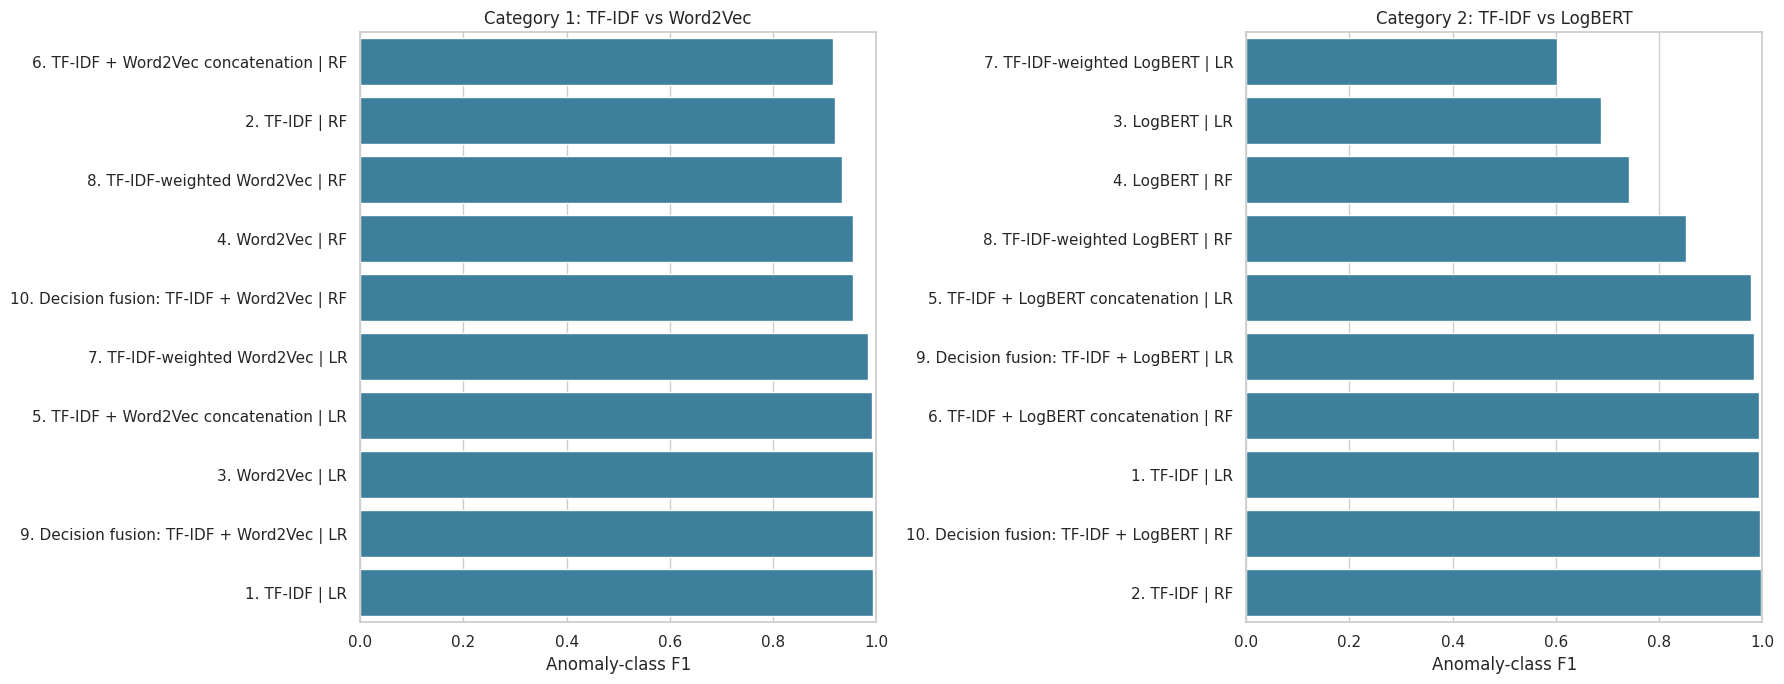

In [18]:
# What: Plot both experiment leaderboards. Why: Make performance differences easy to see.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for axis, table, title in [
    (axes[0], category_1_table, "Category 1: TF-IDF vs Word2Vec"),
    (axes[1], category_2_table, "Category 2: TF-IDF vs LogBERT"),
]:
    plot_table = table.copy()
    plot_table["Label"] = (
        plot_table["Experiment"].astype(str)
        + ". "
        + plot_table["Representation"]
        + " | "
        + plot_table["Classifier"].str.replace("Logistic Regression", "LR")
        .str.replace("Random Forest", "RF")
    )
    plot_table = plot_table.sort_values("F1", ascending=True)
    sns.barplot(data=plot_table, x="F1", y="Label", ax=axis, color="#2E86AB")
    axis.set_xlim(0, 1.0)
    axis.set_title(title)
    axis.set_xlabel("Anomaly-class F1")
    axis.set_ylabel("")

plt.tight_layout()
plt.show()



In [19]:
# What: Export tables and training history. Why: Preserve evidence for the research report.
category_1_path = OUTPUT_DIR / "category_1_results.csv"
category_2_path = OUTPUT_DIR / "category_2_results.csv"
history_path = OUTPUT_DIR / "logbert_training_history.csv"
config_path = OUTPUT_DIR / "experiment_config.json"

category_1_table.to_csv(category_1_path, index=False)
category_2_table.to_csv(category_2_path, index=False)
logbert_history.to_csv(history_path, index=False)

configuration = {
    "seed": SEED,
    "run_mode": RUN_MODE,
    "device": str(DEVICE),
    "dataset": DATA_PATH.name,
    "rows": len(df),
    "sessions": int(df["session_id"].nunique()),
    "rf_trees": RF_TREES,
    "word2vec_dimension": W2V_DIM,
    "word2vec_epochs": W2V_EPOCHS,
    "logbert_dimension": LOGBERT_DIM,
    "logbert_epochs_requested": LOGBERT_EPOCHS,
    "logbert_epochs_completed": int(len(logbert_history)),
}
config_path.write_text(json.dumps(configuration, indent=2))

archive_path = shutil.make_archive(
    "/content/COS700_5G_experiment_results",
    "zip",
    OUTPUT_DIR,
)
print(f"Saved Category 1 table: {category_1_path}")
print(f"Saved Category 2 table: {category_2_path}")
print(f"Saved result archive: {archive_path}")



Saved Category 1 table: /content/cos700_experiment_outputs/category_1_results.csv
Saved Category 2 table: /content/cos700_experiment_outputs/category_2_results.csv
Saved result archive: /content/COS700_5G_experiment_results.zip


<!-- What: Guide interpretation. Why: Prevent unsupported conclusions. -->
## Interpretation checklist

1. Compare methods **within** each category; Category 1 is log-entry level and
   Category 2 is session level.
2. Prioritise anomaly F1, recall, PR-AUC, and false-positive rate rather than
   accuracy alone.
3. Use the validation-selected thresholds and fusion weights; do not retune on
   the test results.
4. Discuss the duplication and template-label findings from the audit when
   interpreting unusually high scores.
5. A hybrid method should be claimed as better only when its test performance
   improves meaningfully over both corresponding standalone representations.
